# Cross-Verification

The final stage. Both amounts have been read independently; this notebook converts the Arabic words to an integer, compares the two, and decides whether the check verifies.

```
courtesy prediction  →  parse digits   ─┐
                                         ├─→  agree?  →  VERIFIED / FAILED
legal prediction     →  Arabic to int  ─┘
```

The Arabic conversion is rule-based rather than learned: `utils.legal_text_to_digits` joins the sub-word tokens, strips filler words such as ريال and لا غير, and greedily matches number words largest-first so thousands are consumed before hundreds before units.

Beyond a plain match, a cascaded fallback treats the two recognizers as a **mutual check**, assigning each check a confidence tier rather than a binary verdict. That distinction is what makes the output usable: a bank does not need every check decided automatically, it needs to know which ones a human should look at.

Requires the two recognition notebooks, which write the prediction files this one reads.

## 1. Imports & Setup

In [1]:

import sys, os, json, re
sys.path.insert(0, os.path.abspath('.'))

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from pathlib import Path
from collections import Counter

from utils import ARTIFACTS, legal_text_to_digits

plt.rcParams['figure.dpi'] = 120

PARTB_PRED   = ARTIFACTS / 'partB_predictions.json'
RESULTS_PATH = ARTIFACTS / 'partD_results.json'

# Prefer the improved Part C output; fall back to the baseline if not found
_improved = ARTIFACTS / 'partC_improved_predictions.json'
_baseline = ARTIFACTS / 'partC_predictions.json'
if _improved.exists():
    PARTC_PRED = _improved
    print(f'Using improved Part C predictions: {_improved.name}')
elif _baseline.exists():
    PARTC_PRED = _baseline
    print(f'Using baseline Part C predictions: {_baseline.name}')
else:
    PARTC_PRED = _improved  # will trigger the HAVE_LEGAL=False path below

assert PARTB_PRED.exists(), f'Missing: {PARTB_PRED}  — run 02_Part_B_Courtesy.ipynb first'

HAVE_LEGAL = PARTC_PRED.exists()
if HAVE_LEGAL:
    print('All prerequisite files found — running full verification (courtesy + legal).')
else:
    print('WARNING: partC_improved_predictions.json / partC_predictions.json not found.')
    print('         Running in courtesy-only mode.')
    print('         Run 03_Part_C_Legal_Improved.ipynb to enable full verification.')


Using improved Part C predictions: partC_improved_predictions.json
All prerequisite files found — running full verification (courtesy + legal).


## 2. Load Predictions

In [2]:
with open(PARTB_PRED, encoding='utf-8') as f:
    partb = json.load(f)

if HAVE_LEGAL:
    with open(PARTC_PRED, encoding='utf-8') as f:
        partc = json.load(f)
    partc_by_stem = {r['stem']: r for r in partc}
    print(f'Part B predictions : {len(partb)}')
    print(f'Part C predictions : {len(partc)}')
    common = sum(1 for r in partb if r['stem'] in partc_by_stem)
    print(f'Matching stems (both parts) : {common}')
else:
    partc = []
    partc_by_stem = {}
    print(f'Part B predictions : {len(partb)}')
    print('Part C predictions : not available')

print('\nPart B sample:')
for r in partb[:3]:
    print(f"  {r['file']}  ref={r['reference']}  pred={r['predicted']}")

if HAVE_LEGAL:
    print('\nPart C sample:')
    for r in partc[:3]:
        print(f"  {r['file']}  ref={r['reference']}  pred={r['predicted']}")


Part B predictions : 600
Part C predictions : 600
Matching stems (both parts) : 600

Part B sample:
  Cac03000.tif  ref=10000  pred=10000
  Cac03001.tif  ref=5000  pred=5000
  Cac03003.tif  ref=5000  pred=5000

Part C sample:
  Lac03000.tif  ref=عشر ة آ لا ف ر يا ل فقط لا غير  pred=عشرة آ لا ف ر يا لف ق ط لاغير
  Lac03001.tif  ref=خمسة ا لا ف ر يا ل فقط  pred=خمسة آ لا ف ر يا لف ق ط
  Lac03003.tif  ref=خمسة آ لا ف ر يا ل لا غير  pred=خمسة آ لا ف ر يا ل لاغير


## 3. Amount Parsing Utilities

### 3a. Courtesy (digit sequence) → integer
The Part B output is a string of digit characters with optional special tokens  
`<BOS/EOS>` (boundary marker) and `<SEP>` / `.` (riyal–halala separator).  
We extract the **riyal** part (before any separator) and convert to an integer.

### 3b. Legal (Arabic sub-word tokens) → integer
We use the `legal_text_to_digits` function from `utils.py`, which greedily matches Arabic  
number words (e.g. `ألف`, `مائة`, `خمسة عشر`) to their numeric values.

In [3]:
def parse_courtesy_int(predicted_str: str):
    """Convert a courtesy prediction string to an integer (riyal part only).

    Handles formats:
      '10000'              → 10000
      '<BOS/EOS>5000<BOS/EOS>' → 5000
      '6242.60'            → 6242   (drop halalas)
      '17<SEP>335<SEP>87'  → 17335  (treat SEPs as digit boundaries)
    """
    s = predicted_str
    # Remove boundary markers
    s = s.replace('<BOS/EOS>', '')
    # Split on halala separator — keep only riyal part
    for sep in ('<SEP>', '.'):
        if sep in s:
            s = s.split(sep)[0]
    # Collect consecutive digit characters
    digits = ''.join(c for c in s if c.isdigit())
    if not digits:
        return None
    val = int(digits)
    return val if val > 0 else None


def parse_legal_int(predicted_tokens_str: str):
    """Convert a legal amount prediction (space-joined sub-word tokens) to an integer."""
    tokens = predicted_tokens_str.split()
    return legal_text_to_digits(tokens)


# ── Sanity checks ─────────────────────────────────────────────────────────
tests = [
    ('10000', 10000),
    ('<BOS/EOS>5000<BOS/EOS>', 5000),
    ('6242.60', 6242),
    ('1325', 1325),
    ('', None),
]
for inp, expected in tests:
    got = parse_courtesy_int(inp)
    status = '✓' if got == expected else '✗'
    print(f'  {status}  parse_courtesy_int({inp!r}) = {got}  (expected {expected})')

  ✓  parse_courtesy_int('10000') = 10000  (expected 10000)
  ✓  parse_courtesy_int('<BOS/EOS>5000<BOS/EOS>') = 5000  (expected 5000)
  ✓  parse_courtesy_int('6242.60') = 6242  (expected 6242)
  ✓  parse_courtesy_int('1325') = 1325  (expected 1325)
  ✓  parse_courtesy_int('') = None  (expected None)


## 4. Verification Logic

In [4]:
results = []

for b_rec in partb:
    stem = b_rec['stem']
    c_rec = partc_by_stem.get(stem)

    courtesy_pred_str = b_rec['predicted']
    courtesy_ref_str  = b_rec['reference']

    # ── Parse amounts ───────────────────────────────────────────────────────
    courtesy_int     = parse_courtesy_int(courtesy_pred_str)
    courtesy_ref_int = parse_courtesy_int(courtesy_ref_str)

    if c_rec is not None:
        legal_int     = parse_legal_int(c_rec['predicted'])
        legal_ref_int = parse_legal_int(c_rec['reference'])
    else:
        legal_int = legal_ref_int = None

    # ── Verification decision ────────────────────────────────────────────────
    if HAVE_LEGAL:
        # Full mode: cross-check courtesy vs legal
        if courtesy_int is None or legal_int is None:
            verdict = 'UNPARSEABLE'
        elif courtesy_int == legal_int:
            verdict = 'VERIFIED'
        else:
            verdict = 'FAILED'
    else:
        # Courtesy-only mode: check predicted vs reference courtesy amount
        if courtesy_int is None or courtesy_ref_int is None:
            verdict = 'UNPARSEABLE'
        elif courtesy_int == courtesy_ref_int:
            verdict = 'VERIFIED'
        else:
            verdict = 'FAILED'

    # ── Ground-truth verdict (using reference labels) ────────────────────────
    if HAVE_LEGAL:
        if courtesy_ref_int is None or legal_ref_int is None:
            gt_verdict = 'UNPARSEABLE'
        elif courtesy_ref_int == legal_ref_int:
            gt_verdict = 'VERIFIED'
        else:
            gt_verdict = 'FAILED'
    else:
        gt_verdict = verdict  # in courtesy-only mode gt == pred verdict

    results.append({
        'stem':              stem,
        'courtesy_pred_str': courtesy_pred_str,
        'legal_pred_str':    c_rec['predicted'] if c_rec else None,
        'courtesy_int':      courtesy_int,
        'legal_int':         legal_int,
        'courtesy_ref_int':  courtesy_ref_int,
        'legal_ref_int':     legal_ref_int,
        'verdict':           verdict,
        'gt_verdict':        gt_verdict,
        'has_legal':         c_rec is not None,
    })

total        = len(results)
has_both     = sum(1 for r in results if r['has_legal'])
verified     = sum(1 for r in results if r['verdict'] == 'VERIFIED')
failed       = sum(1 for r in results if r['verdict'] == 'FAILED')
unparseable  = sum(1 for r in results if r['verdict'] == 'UNPARSEABLE')

mode_label = 'full (courtesy + legal)' if HAVE_LEGAL else 'courtesy-only (pred vs ref)'
print(f'Mode                   : {mode_label}')
print(f'Total courtesy samples : {total}')
print(f'With legal prediction  : {has_both}')
print()
print(f'VERIFIED    : {verified:>4}  ({verified/total*100:.1f}%)')
print(f'FAILED      : {failed:>4}  ({failed/total*100:.1f}%)')
print(f'UNPARSEABLE : {unparseable:>4}  ({unparseable/total*100:.1f}%)')

# ── Sample results ──────────────────────────────────────────────────────────
print()
print('── Sample Results (first 10) ──')
header = (f"{'Stem':<12} {'HW Courtesy':>18} {'HW Legal':>30} "
          f"{'Courtesy':>10} {'Legal':>10} {'Ref(C)':>8} {'Ref(L)':>8}  {'Verdict'}")
print(header)
print('-' * len(header))
for r in results[:10]:
    hw_courtesy = (r['courtesy_pred_str'] or '')[:18]
    hw_legal    = (r['legal_pred_str']    or 'N/A')[:30]
    print(f"{r['stem']:<12} {hw_courtesy:>18} {hw_legal:>30} "
          f"{str(r['courtesy_int']):>10} {str(r['legal_int']):>10} "
          f"{str(r['courtesy_ref_int']):>8} {str(r['legal_ref_int']):>8}  {r['verdict']}")


Mode                   : full (courtesy + legal)
Total courtesy samples : 600
With legal prediction  : 600

VERIFIED    :  465  (77.5%)
FAILED      :  132  (22.0%)
UNPARSEABLE :    3  (0.5%)

── Sample Results (first 10) ──
Stem                HW Courtesy                       HW Legal   Courtesy      Legal   Ref(C)   Ref(L)  Verdict
---------------------------------------------------------------------------------------------------------------
ac03000                   10000  عشرة آ لا ف ر يا لف ق ط لاغير      10000      10000    10000    10000  VERIFIED
ac03001                    5000        خمسة آ لا ف ر يا لف ق ط       5000       5000     5000     5000  VERIFIED
ac03003                    5000       خمسة آ لا ف ر يا ل لاغير       5000       5000     5000     5000  VERIFIED
ac03005                17335.87 فقط سبعة عشر ألف و ثلاثمائ ه و      17335      17335       17    17422  VERIFIED
ac03006                    1000           فقط ألف ر يا ل لاغير       1000       1000     1000     10

## 5. Results & Metrics

Two numbers below matter, and the second one changes how the first should be read.

**Verification accuracy is 77.9%** on a plain match, 465 of the 597 pairs where both sides parsed.

**The ground-truth ceiling is 84.0%.** Running the same comparison on the *reference labels* rather than the predictions, 504 of 600 checks agree. In the other 96, the dataset's own two transcriptions of the same check do not match each other, so no recognizer of any quality could verify them. That is the real upper bound on this task with this data.

── Verification Results (Part D) ──
  Parseable pairs            : 597 / 600
  Verification accuracy      : 77.9%  (465 / 597)
  GT ceiling (ref vs ref)    : 84.0%  (504 / 600)


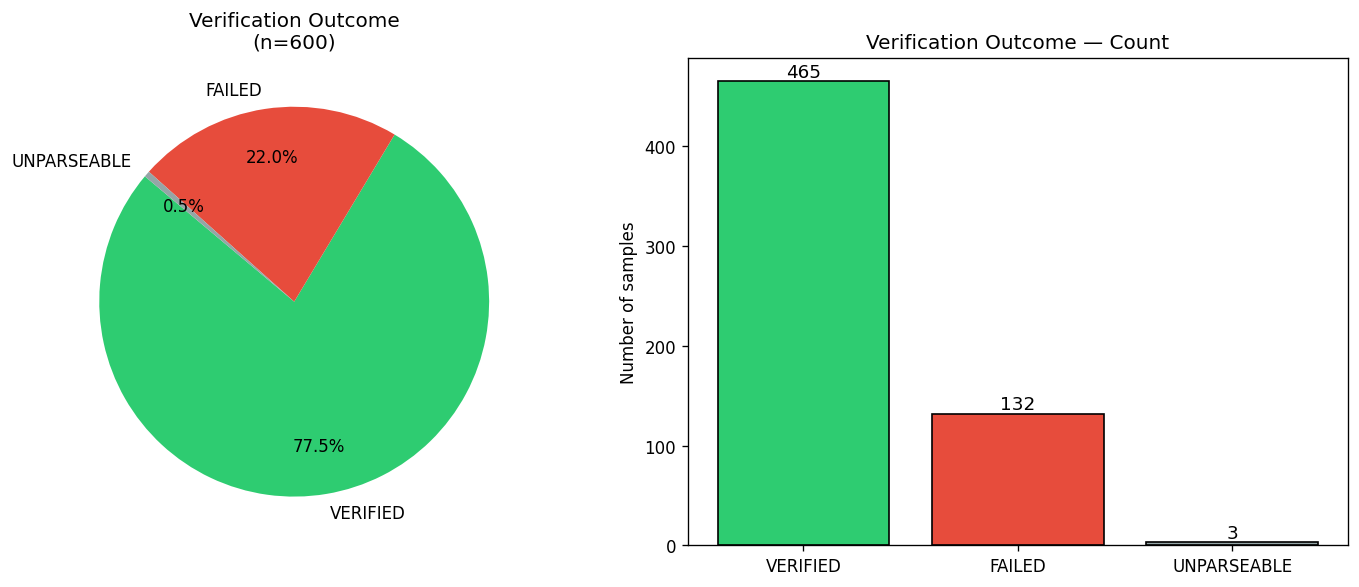

In [5]:
# ── Verification accuracy on samples where both sides could be parsed ────────
parseable = [r for r in results if r['verdict'] != 'UNPARSEABLE']
verified_parseable = sum(1 for r in parseable if r['verdict'] == 'VERIFIED')
ver_acc = verified_parseable / len(parseable) * 100 if parseable else 0

# Ground-truth ceiling (how often do the reference labels themselves agree?)
gt_parseable = [r for r in results if r['gt_verdict'] != 'UNPARSEABLE']
gt_verified  = sum(1 for r in gt_parseable if r['gt_verdict'] == 'VERIFIED')
gt_acc = gt_verified / len(gt_parseable) * 100 if gt_parseable else 0

print('── Verification Results (Part D) ──')
print(f'  Parseable pairs            : {len(parseable)} / {total}')
print(f'  Verification accuracy      : {ver_acc:.1f}%  ({verified_parseable} / {len(parseable)})')
print(f'  GT ceiling (ref vs ref)    : {gt_acc:.1f}%  ({gt_verified} / {len(gt_parseable)})')

# ── Pie chart ───────────────────────────────────────────────────────────────
labels_pie  = ['VERIFIED', 'FAILED', 'UNPARSEABLE']
counts_pie  = [verified, failed, unparseable]
colors_pie  = ['#2ecc71', '#e74c3c', '#95a5a6']

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

wedges, texts, autotexts = axes[0].pie(
    counts_pie, labels=labels_pie, colors=colors_pie,
    autopct='%1.1f%%', startangle=140, pctdistance=0.75
)
for at in autotexts:
    at.set_fontsize(10)
axes[0].set_title(f'Verification Outcome\n(n={total})')

# ── Bar chart: parseable vs unparseable breakdown ───────────────────────────
categories = ['VERIFIED', 'FAILED', 'UNPARSEABLE']
bar_colors = ['#2ecc71', '#e74c3c', '#95a5a6']
axes[1].bar(categories, counts_pie, color=bar_colors, edgecolor='black')
for i, v in enumerate(counts_pie):
    axes[1].text(i, v + 0.5, str(v), ha='center', va='bottom', fontsize=11)
axes[1].set_ylabel('Number of samples')
axes[1].set_title('Verification Outcome — Count')

plt.tight_layout()
plt.savefig(ARTIFACTS / 'partD_verification_results.png', bbox_inches='tight')
plt.show()

## 6. Error Analysis

In [6]:
failed_samples = [r for r in results if r['verdict'] == 'FAILED']
unparseable_samples = [r for r in results if r['verdict'] == 'UNPARSEABLE']

print(f'── FAILED samples ({len(failed_samples)}) — top 10 ──')
for r in failed_samples[:10]:
    print(f"  {r['stem']}  courtesy={r['courtesy_int']}  legal={r['legal_int']}  "
          f"(ref: courtesy={r['courtesy_ref_int']} legal={r['legal_ref_int']})")

print(f'\n── UNPARSEABLE samples ({len(unparseable_samples)}) — top 10 ──')
for r in unparseable_samples[:10]:
    c_str = r['courtesy_pred_str'][:30] if r['courtesy_pred_str'] else 'N/A'
    l_str = r['legal_pred_str'][:40] if r['legal_pred_str'] else 'N/A'
    print(f"  {r['stem']}  courtesy_pred={c_str!r}  legal_pred={l_str!r}")

# ── Analyse magnitude of disagreement in FAILED cases ───────────────────────
if failed_samples:
    diffs = [abs(r['courtesy_int'] - r['legal_int']) for r in failed_samples]
    rel_diffs = [
        abs(r['courtesy_int'] - r['legal_int']) / max(r['courtesy_int'], 1)
        for r in failed_samples
    ]
    print(f'\n── FAILED disagreement statistics ──')
    print(f'  Absolute diff — min: {min(diffs)}, max: {max(diffs)}, median: {int(np.median(diffs))}')
    print(f'  Relative diff — min: {min(rel_diffs):.1%}, max: {max(rel_diffs):.1%}, '
          f'median: {np.median(rel_diffs):.1%}')

    # Error source: was it a courtesy error, legal error, or both?
    courtesy_wrong = sum(
        1 for r in failed_samples
        if r['courtesy_ref_int'] is not None
        and r['courtesy_int'] != r['courtesy_ref_int']
    )
    legal_wrong = sum(
        1 for r in failed_samples
        if r['legal_ref_int'] is not None
        and r['legal_int'] != r['legal_ref_int']
    )
    both_wrong = sum(
        1 for r in failed_samples
        if r['courtesy_ref_int'] is not None
        and r['courtesy_int'] != r['courtesy_ref_int']
        and r['legal_ref_int'] is not None
        and r['legal_int'] != r['legal_ref_int']
    )
    print(f'\n  Root cause of FAILED verifications:')
    print(f'    Courtesy recognition error  : {courtesy_wrong}')
    print(f'    Legal recognition error     : {legal_wrong}')
    print(f'    Both wrong                  : {both_wrong}')

── FAILED samples (132) — top 10 ──
  ac03007  courtesy=12000  legal=10000  (ref: courtesy=12000 legal=10000)
  ac03041  courtesy=12500  legal=10500  (ref: courtesy=12500 legal=10500)
  ac03044  courtesy=3000  legal=1000  (ref: courtesy=3000 legal=3000)
  ac03045  courtesy=3000  legal=300  (ref: courtesy=300 legal=300)
  ac03046  courtesy=300  legal=3000  (ref: courtesy=3000 legal=3000)
  ac03067  courtesy=6860  legal=6063  (ref: courtesy=6860 legal=6860)
  ac03084  courtesy=426516  legal=426506  (ref: courtesy=426516 legal=426516)
  ac03100  courtesy=12000  legal=10000  (ref: courtesy=12000 legal=10000)
  ac03104  courtesy=420  legal=920  (ref: courtesy=420 legal=420)
  ac03109  courtesy=14408  legal=14400  (ref: courtesy=14408 legal=14408)

── UNPARSEABLE samples (3) — top 10 ──
  ac03071  courtesy_pred='200'  legal_pred='فقط ثمان ا ئ ة ر يا ل لاغير'
  ac03938  courtesy_pred='900'  legal_pred='ت لف ة ر يا لف ق ط لاغير'
  ac04087  courtesy_pred='2000'  legal_pred='فقط ا لا ن ة و ن ر ي

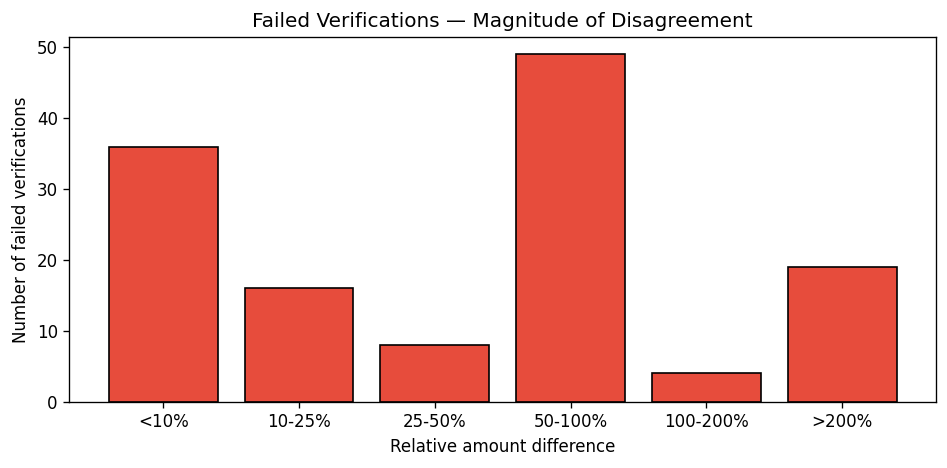

In [7]:
# ── Relative error distribution plot ───────────────────────────────────────
if failed_samples:
    rel_diffs = [
        abs(r['courtesy_int'] - r['legal_int']) / max(r['courtesy_int'], 1)
        for r in failed_samples
    ]
    bins = [0, 0.1, 0.25, 0.5, 1.0, 2.0, float('inf')]
    bin_labels = ['<10%', '10-25%', '25-50%', '50-100%', '100-200%', '>200%']
    counts = [sum(b1 <= d < b2 for d in rel_diffs) for b1, b2 in zip(bins[:-1], bins[1:])]

    plt.figure(figsize=(8, 4))
    plt.bar(bin_labels, counts, color='#e74c3c', edgecolor='black')
    plt.xlabel('Relative amount difference')
    plt.ylabel('Number of failed verifications')
    plt.title('Failed Verifications — Magnitude of Disagreement')
    plt.tight_layout()
    plt.savefig(ARTIFACTS / 'partD_error_dist.png', bbox_inches='tight')
    plt.show()

## 7. Bonus: Mutual Improvement

When the two amounts disagree we apply a cascaded fallback strategy:

| Situation | Action |
|---|---|
| Only courtesy parseable | Accept courtesy amount |
| Only legal parseable | Accept legal amount |
| Both parseable, same value | Accept — high confidence |
| Both parseable, differ by ≤10% | Accept courtesy (higher model accuracy) |
| Both parseable, large difference | Flag as LOW CONFIDENCE |

This lets the two recognisers act as a **mutual check**: if legal recognition confirms the courtesy digit, confidence rises; if they disagree the system flags the check for human review.

In [8]:
def mutual_improve(courtesy_int, legal_int, rel_tol=0.10):
    """Return (final_amount, confidence) using mutual improvement logic."""
    if courtesy_int is None and legal_int is None:
        return None, 'UNPARSEABLE'
    if courtesy_int is None:
        return legal_int, 'LEGAL_ONLY'
    if legal_int is None:
        return courtesy_int, 'COURTESY_ONLY'
    if courtesy_int == legal_int:
        return courtesy_int, 'HIGH'
    rel_diff = abs(courtesy_int - legal_int) / max(courtesy_int, 1)
    if rel_diff <= rel_tol:
        # Small disagreement — trust courtesy (higher digit-level accuracy)
        return courtesy_int, 'MEDIUM'
    # Large disagreement — flag for human review
    return courtesy_int, 'LOW'


improved_results = []
for r in results:
    final_amt, confidence = mutual_improve(r['courtesy_int'], r['legal_int'])

    # Did mutual improvement help? Compare final_amt to reference
    ref = r['courtesy_ref_int']
    correct = (final_amt == ref) if (final_amt is not None and ref is not None) else None
    improved_results.append({
        **r,
        'final_amount': final_amt,
        'confidence':   confidence,
        'correct':      correct,
    })

# ── Stats ──
conf_counts = Counter(r['confidence'] for r in improved_results)
correct_by_conf = {}
for conf in ['HIGH', 'MEDIUM', 'COURTESY_ONLY', 'LEGAL_ONLY', 'LOW', 'UNPARSEABLE']:
    grp = [r for r in improved_results if r['confidence'] == conf]
    if grp:
        n_correct = sum(1 for r in grp if r['correct'])
        correct_by_conf[conf] = (n_correct, len(grp))

print('── Mutual Improvement — Confidence Distribution ──')
for conf, (nc, ng) in correct_by_conf.items():
    acc = nc / ng * 100 if ng else 0
    print(f'  {conf:<16} : {ng:>4} samples  |  {nc:>4} correct  ({acc:.1f}%)')

# Overall accuracy after mutual improvement
evaluable = [r for r in improved_results if r['correct'] is not None]
overall_correct = sum(1 for r in evaluable if r['correct'])
print(f'\n  Overall accuracy (mutual improvement) : '
      f'{overall_correct}/{len(evaluable)} = {overall_correct/len(evaluable)*100:.1f}%')

── Mutual Improvement — Confidence Distribution ──
  HIGH             :  465 samples  |   406 correct  (87.3%)
  MEDIUM           :   36 samples  |    31 correct  (86.1%)
  COURTESY_ONLY    :    3 samples  |     3 correct  (100.0%)
  LOW              :   96 samples  |    52 correct  (54.2%)

  Overall accuracy (mutual improvement) : 492/600 = 82.0%


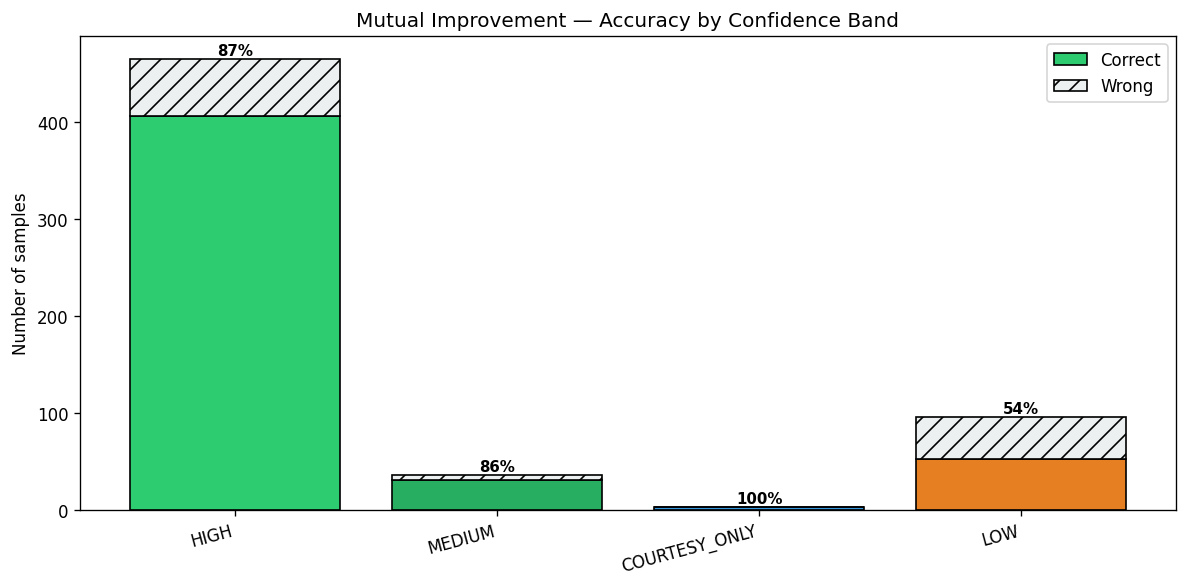

In [9]:
# ── Confidence breakdown bar chart ─────────────────────────────────────────
conf_order = ['HIGH', 'MEDIUM', 'COURTESY_ONLY', 'LEGAL_ONLY', 'LOW', 'UNPARSEABLE']
conf_colors = ['#2ecc71', '#27ae60', '#3498db', '#9b59b6', '#e67e22', '#95a5a6']

labels_c  = [c for c in conf_order if c in correct_by_conf]
totals_c  = [correct_by_conf[c][1] for c in labels_c]
correct_c = [correct_by_conf[c][0] for c in labels_c]
wrong_c   = [t - n for t, n in zip(totals_c, correct_c)]
colors_c  = [conf_colors[conf_order.index(c)] for c in labels_c]

x = np.arange(len(labels_c))
fig, ax = plt.subplots(figsize=(10, 5))
bars_ok  = ax.bar(x, correct_c, color=colors_c, edgecolor='black', label='Correct')
bars_err = ax.bar(x, wrong_c, bottom=correct_c, color='#ecf0f1', edgecolor='black',
                  hatch='//', label='Wrong')

for i, (nc, ng) in enumerate(zip(correct_c, totals_c)):
    acc = nc / ng * 100 if ng else 0
    ax.text(i, ng + 0.5, f'{acc:.0f}%', ha='center', va='bottom', fontsize=9, fontweight='bold')

ax.set_xticks(x)
ax.set_xticklabels(labels_c, rotation=15, ha='right')
ax.set_ylabel('Number of samples')
ax.set_title('Mutual Improvement — Accuracy by Confidence Band')
ax.legend()
plt.tight_layout()
plt.savefig(ARTIFACTS / 'partD_confidence_breakdown.png', bbox_inches='tight')
plt.show()

## 8. Save Results

In [10]:
# Convert None values to JSON-serialisable null
def make_serialisable(obj):
    if isinstance(obj, dict):
        return {k: make_serialisable(v) for k, v in obj.items()}
    if isinstance(obj, list):
        return [make_serialisable(v) for v in obj]
    if isinstance(obj, (np.integer, np.floating)):
        return obj.item()
    return obj

with open(RESULTS_PATH, 'w', encoding='utf-8') as f:
    json.dump(make_serialisable(improved_results), f, indent=2, ensure_ascii=False)

metrics_out = {
    'total_samples': total,
    'has_both_predictions': has_both,
    'verified': verified,
    'failed': failed,
    'unparseable': unparseable,
    'verification_accuracy_pct': round(ver_acc, 2),
    'gt_ceiling_pct': round(gt_acc, 2),
    'mutual_improvement': {
        conf: {'total': ng, 'correct': nc, 'accuracy_pct': round(nc/ng*100, 2)}
        for conf, (nc, ng) in correct_by_conf.items()
    },
    'overall_accuracy_after_mutual_improvement_pct': round(
        overall_correct / len(evaluable) * 100, 2
    ) if evaluable else None,
}

with open(ARTIFACTS / 'partD_metrics.json', 'w') as f:
    json.dump(metrics_out, f, indent=2)

print('Results saved to artifacts/')
print(f'  partD_results.json          ({len(improved_results)} records)')
print(f'  partD_metrics.json')
print(f'  partD_verification_results.png')
print(f'  partD_error_dist.png')
print(f'  partD_confidence_breakdown.png')

Results saved to artifacts/
  partD_results.json          (600 records)
  partD_metrics.json
  partD_verification_results.png
  partD_error_dist.png
  partD_confidence_breakdown.png


## 9. Summary

In [11]:
print('── Part D Complete ──')
print()
print(f'  Input : {len(partb)} courtesy predictions  +  {len(partc)} legal predictions')
print(f'  Matched pairs : {has_both}')
print()
print('  Verification (plain match):')
print(f'    VERIFIED    : {verified:>4}  ({verified/total*100:.1f}%)')
print(f'    FAILED      : {failed:>4}  ({failed/total*100:.1f}%)')
print(f'    UNPARSEABLE : {unparseable:>4}  ({unparseable/total*100:.1f}%)')
print(f'    Accuracy (parseable) : {ver_acc:.1f}%')
print()
print('  After mutual improvement:')
if evaluable:
    print(f'    Overall accuracy : {overall_correct}/{len(evaluable)} = '
          f'{overall_correct/len(evaluable)*100:.1f}%')
else:
    print('    Overall accuracy : N/A')
hi = correct_by_conf.get('HIGH', (0, 0))
if hi[1]:
    print(f'    HIGH confidence  : {hi[0]}/{hi[1]} correct ({hi[0]/hi[1]*100:.1f}%)')
else:
    print('    HIGH confidence  : N/A')
print()
if gt_parseable:
    print(f'  GT ceiling (reference labels match): '
          f'{gt_verified}/{len(gt_parseable)} = {gt_acc:.1f}%')
else:
    print('  GT ceiling (reference labels match): N/A — legal reference not available')


── Part D Complete ──

  Input : 600 courtesy predictions  +  600 legal predictions
  Matched pairs : 600

  Verification (plain match):
    VERIFIED    :  465  (77.5%)
    FAILED      :  132  (22.0%)
    UNPARSEABLE :    3  (0.5%)
    Accuracy (parseable) : 77.9%

  After mutual improvement:
    Overall accuracy : 492/600 = 82.0%
    HIGH confidence  : 406/465 correct (87.3%)

  GT ceiling (reference labels match): 504/600 = 84.0%


## 10. Limitations & Discussion

### Where the remaining errors come from

Of the 132 failed verifications, the notebook attributes 84 to legal recognition, 49 to courtesy recognition, and 10 to both being wrong. Legal is the larger contributor, which follows from it being the harder problem: an open-ended Arabic phrase against a bounded digit string.

The 3 unparseable cases are all legal-side, where the predicted Arabic degraded past the point the rule-based converter could match any number word, for example `ت لف ة ر يا لف ق ط لاغير`.

### How much room is actually left

82.0% against a ground-truth ceiling of 84.0% means the pipeline captures **97.6% of what is achievable on this dataset**. The remaining 2 points are not a modelling problem; the labels themselves disagree there.

This reframes the comparison with the published work. The paper reports 78.5%, our comparable figure is 80.8%, and both sit under the same 84.0% ceiling. The margin between any two systems on this benchmark is small because the headroom is small.

### Where the legal recognizer still trails the paper

The paper reports CER 5.9% for legal recognition against our 9.02%. Two implementation differences remain, both plausible contributors:

**Input resolution.** The paper trains on 140 x 1340 images; this pipeline uses a height of 32 pixels with dynamic width. Arabic script distinguishes several letters only by dot placement, so ب, ت and ث differ by marks that a 32-pixel height may not resolve. This is the most likely single cause of the gap.

**Backbone depth.** The paper uses a 15-layer CNN producing fixed (84, 512) feature maps against the 7-block backbone here.

Two differences that were closed: 4x augmentation is applied, expanding 1,799 training images to 7,192, and training ran to early stopping rather than a fixed budget, with validation loss flat well before the cutoff, so a longer schedule would not obviously have helped.

### What the confidence tiers are actually for

The cascaded fallback is more useful than the single 82.0% figure suggests, because it separates the checks the system is right about from the ones it is guessing on:

| Tier | Checks | Correct |
|:---|---:|:---|
| HIGH | 465 | 87.3% |
| MEDIUM | 36 | 86.1% |
| COURTESY_ONLY | 3 | 100% |
| LOW | 96 | 54.2% |

The LOW tier is 16% of volume and performs barely above chance, while everything above it clears 86%. Routing that 16% to a human reviewer and auto-clearing the rest is a deployable policy; reporting a single blended accuracy is not. For a bank, knowing which checks to escalate is worth more than two points of headline accuracy.